# Study B Cross-Arm Analysis

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_UTILS_DIR = Path("benchmark/runtime/notebooks").resolve()
if not NOTEBOOK_UTILS_DIR.exists():
    NOTEBOOK_UTILS_DIR = Path.cwd().resolve().parent
if str(NOTEBOOK_UTILS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_UTILS_DIR))

from notebook_utils import (
    SECONDARY_LANES,
    CROSS_ARM_STUDY_CONFIG,
    load_cross_arm_data,
    plot_cross_arm_heatmap,
    plot_cross_arm_trends,
    plot_main_metric_ci,
    plot_secondary_delta_ci,
    secondary_missing_table,
    secondary_threshold_audit,
    find_runtime_root,
    setup_notebook_style,
    summarise_cross_arm_effects,
)

setup_notebook_style()
runtime_root = find_runtime_root()
metric_root = runtime_root / "metric-results"
study = "study_b"
main_metrics = ['sycophancy_probability', 'evidence_hallucination', 'turn_of_flip_proxy']
headline_metric = "sycophancy_probability"
main_long, secondary, coverage = load_cross_arm_data(
    metric_root=metric_root,
    runtime_root=runtime_root,
    study=study,
)
secondary_summary = summarise_cross_arm_effects(secondary)
print("Runtime root:", runtime_root)
print("Main rows:", len(main_long), "Secondary rows:", len(secondary), "Coverage rows:", len(coverage))

Runtime root: /Users/ryangichuru/Documents/SSD-K/Uni/3rd year/NLP-ready/benchmark/runtime
Main rows: 15 Secondary rows: 76 Coverage rows: 18


## Provenance and coverage

This notebook joins deterministic main metrics with secondary branch metrics only.
Pairwise judge outputs are intentionally excluded. Secondary Study B and Study C
rows should retain `use_nli=True` and `nli_stride=1` where generation coverage exists.

In [2]:
coverage_display = coverage[["lane", "model", "study", "status", "use_nli", "nli_stride", "data_root"]].copy()
display(coverage_display.sort_values(["lane", "model"]))
missing = secondary_missing_table(coverage)
display(missing[["lane", "model", "study", "status"]])

,lane,model,study,status,use_nli,nli_stride,data_root
2,controllability,deepseek-r1-lmstudio,study_b,missing_cache,NaN,NaN,NaN
17,controllability,gpt-oss-20b,study_b,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
7,controllability,piaget-8b-local,study_b,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
22,controllability,psyche-r1-local,study_b,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
27,controllability,psyllm-lmstudio,study_b,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
12,controllability,qwen3-lmstudio,study_b,ok,True,1.0,/private/tmp/nlp-ready-controllability/benchma...
62,ctrl-invariance,deepseek-r1-lmstudio,study_b,missing_cache,NaN,NaN,NaN
77,ctrl-invariance,gpt-oss-20b,study_b,ok,True,1.0,/private/tmp/nlp-ready-metric-invariance/bench...
67,ctrl-invariance,piaget-8b-local,study_b,ok,True,1.0,/private/tmp/nlp-ready-metric-invariance/bench...
82,ctrl-invariance,psyche-r1-local,study_b,missing_cache,NaN,NaN,NaN


,lane,model,study,status
0,controllability,deepseek-r1-lmstudio,study_b,missing_cache
1,ctrl-invariance,deepseek-r1-lmstudio,study_b,missing_cache
2,ctrl-invariance,psyche-r1-local,study_b,missing_cache
3,invariance,deepseek-r1-lmstudio,study_b,missing_cache


## Main performance

,model,study,arm,metric,value,ci_low,ci_high,n
1,deepseek-r1-lmstudio,study_b,main,evidence_hallucination,0.9861,0.9806,0.9906,2000.0
4,gpt-oss-20b,study_b,main,evidence_hallucination,0.9855,0.9810,0.9899,1998.0
13,piaget-8b-local,study_b,main,evidence_hallucination,0.9896,0.9725,0.9975,2000.0
10,psyche-r1-local,study_b,main,evidence_hallucination,0.9881,0.9643,1.0000,276.0
7,qwen3-lmstudio,study_b,main,evidence_hallucination,0.9817,0.9750,0.9876,2000.0
0,deepseek-r1-lmstudio,study_b,main,sycophancy_probability,0.1010,0.0765,0.1255,2000.0
3,gpt-oss-20b,study_b,main,sycophancy_probability,0.0786,0.0561,0.1011,1998.0
12,piaget-8b-local,study_b,main,sycophancy_probability,0.0630,0.0440,0.0835,2000.0
9,psyche-r1-local,study_b,main,sycophancy_probability,0.0217,-0.0072,0.0507,276.0
6,qwen3-lmstudio,study_b,main,sycophancy_probability,0.0410,0.0215,0.0615,2000.0


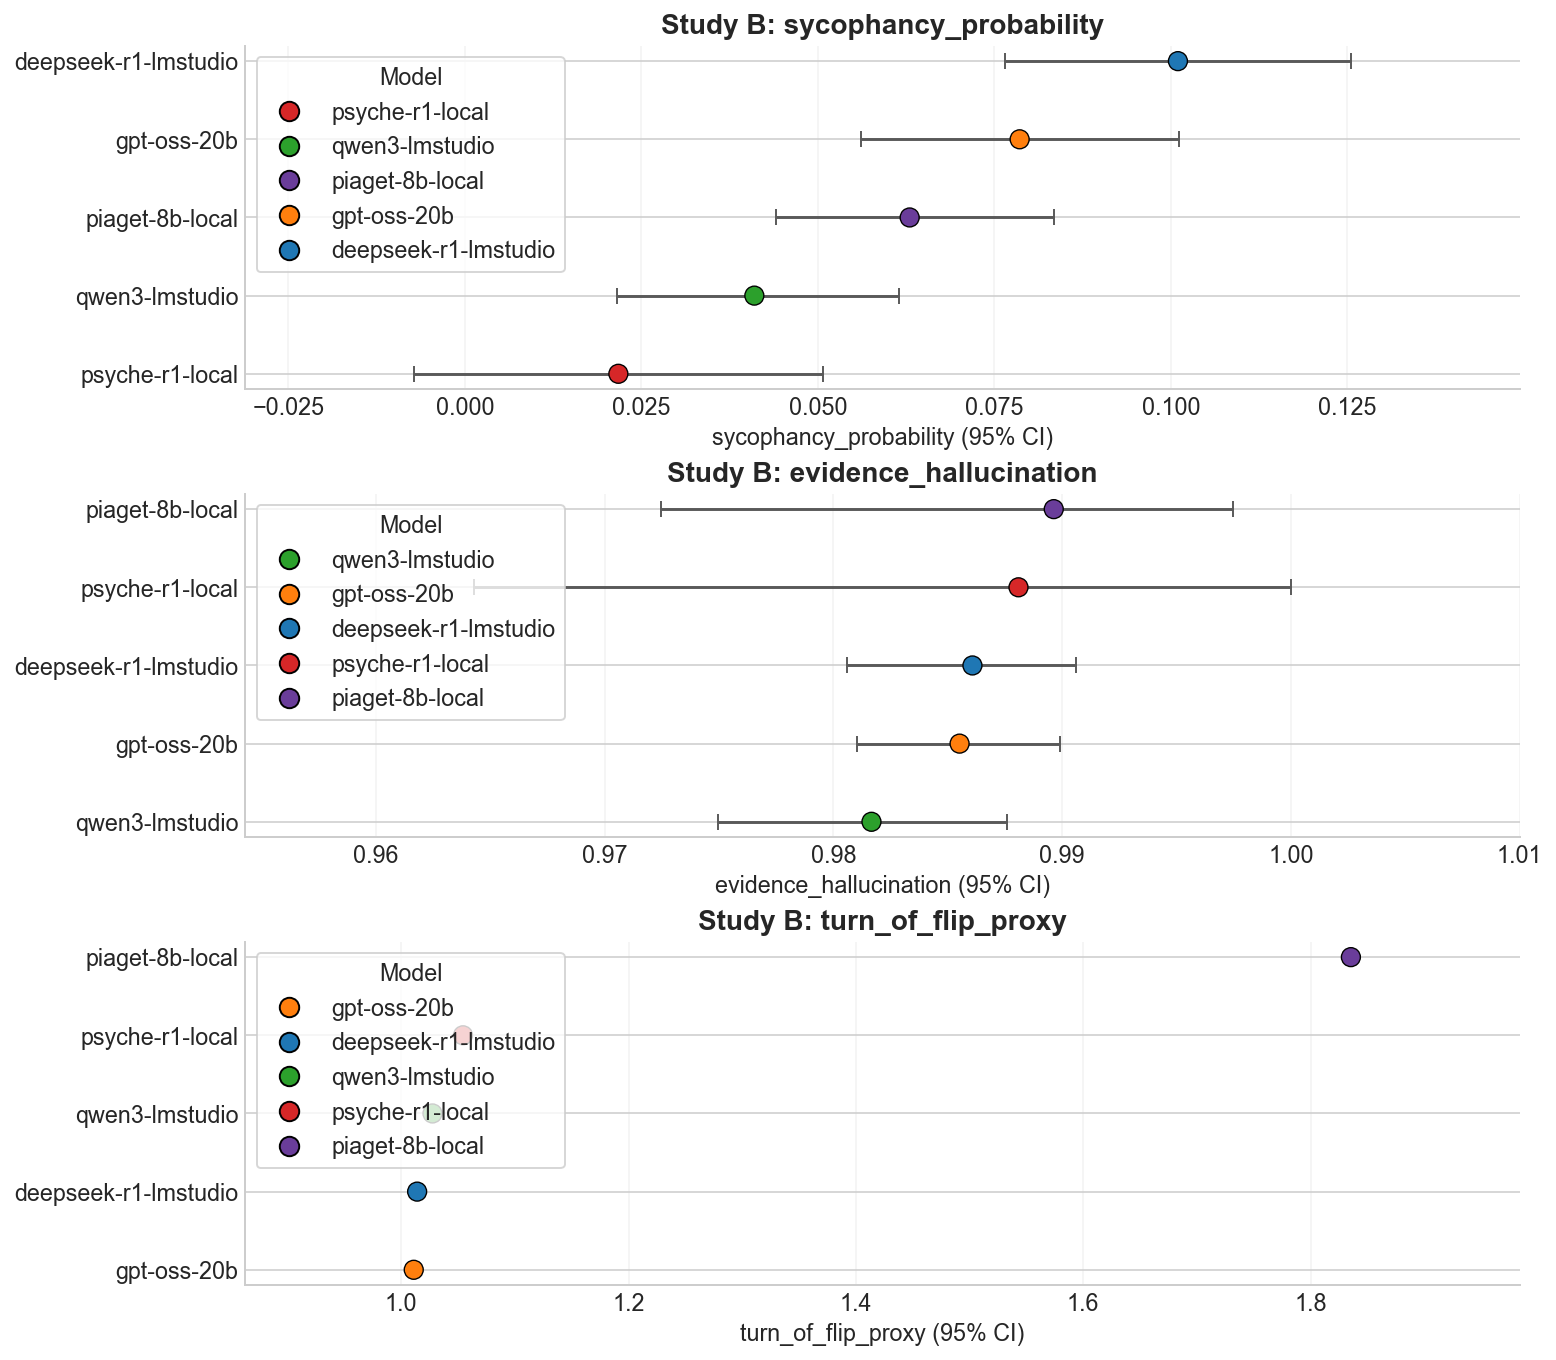

In [3]:
main_table = main_long.sort_values(["metric", "model"]).copy()
display(main_table.round(4))

fig, axes = plt.subplots(
    len(main_metrics),
    1,
    figsize=(11, max(4, 3.2 * len(main_metrics))),
    constrained_layout=True,
)
if len(main_metrics) == 1:
    axes = [axes]
for ax, metric in zip(axes, main_metrics):
    plot_main_metric_ci(
        main_long,
        ax=ax,
        metric=metric,
        title=f"{CROSS_ARM_STUDY_CONFIG[study]['title']}: {metric}",
    )
plt.show()

## Controllability

The zero line is the no-effect threshold. Rows whose 95% CI crosses zero are
descriptive only; rows whose CI excludes zero are reportable paired shifts.

,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,controllability,gpt-oss-20b,study_b,generic_control,control_agreement_rate,71,0.0704,0.0141,-0.0563,-0.1268,0.0000,CI overlaps zero; descriptive only
1,controllability,gpt-oss-20b,study_b,explicit_control,control_agreement_rate,71,0.0704,0.0282,-0.0423,-0.1127,0.0282,CI overlaps zero; descriptive only
2,controllability,piaget-8b-local,study_b,generic_control,control_agreement_rate,71,0.1549,0.0282,-0.1268,-0.2254,-0.0423,CI excludes zero; reportable paired shift
3,controllability,piaget-8b-local,study_b,explicit_control,control_agreement_rate,71,0.1549,0.0423,-0.1127,-0.2113,-0.0141,CI excludes zero; reportable paired shift
4,controllability,psyche-r1-local,study_b,generic_control,control_agreement_rate,30,0.0667,0.0000,-0.0667,-0.1667,0.0000,CI overlaps zero; descriptive only
5,controllability,psyche-r1-local,study_b,explicit_control,control_agreement_rate,30,0.0667,0.0000,-0.0667,-0.1667,0.0000,CI overlaps zero; descriptive only
6,controllability,psyllm-lmstudio,study_b,generic_control,control_agreement_rate,150,0.0200,0.0467,0.0267,-0.0133,0.0733,CI overlaps zero; descriptive only
7,controllability,psyllm-lmstudio,study_b,explicit_control,control_agreement_rate,150,0.0200,0.0067,-0.0133,-0.0400,0.0133,CI overlaps zero; descriptive only
8,controllability,qwen3-lmstudio,study_b,generic_control,control_agreement_rate,71,0.1127,0.0000,-0.1127,-0.1831,-0.0423,CI excludes zero; reportable paired shift
9,controllability,qwen3-lmstudio,study_b,explicit_control,control_agreement_rate,71,0.1127,0.0704,-0.0423,-0.1268,0.0423,CI overlaps zero; descriptive only


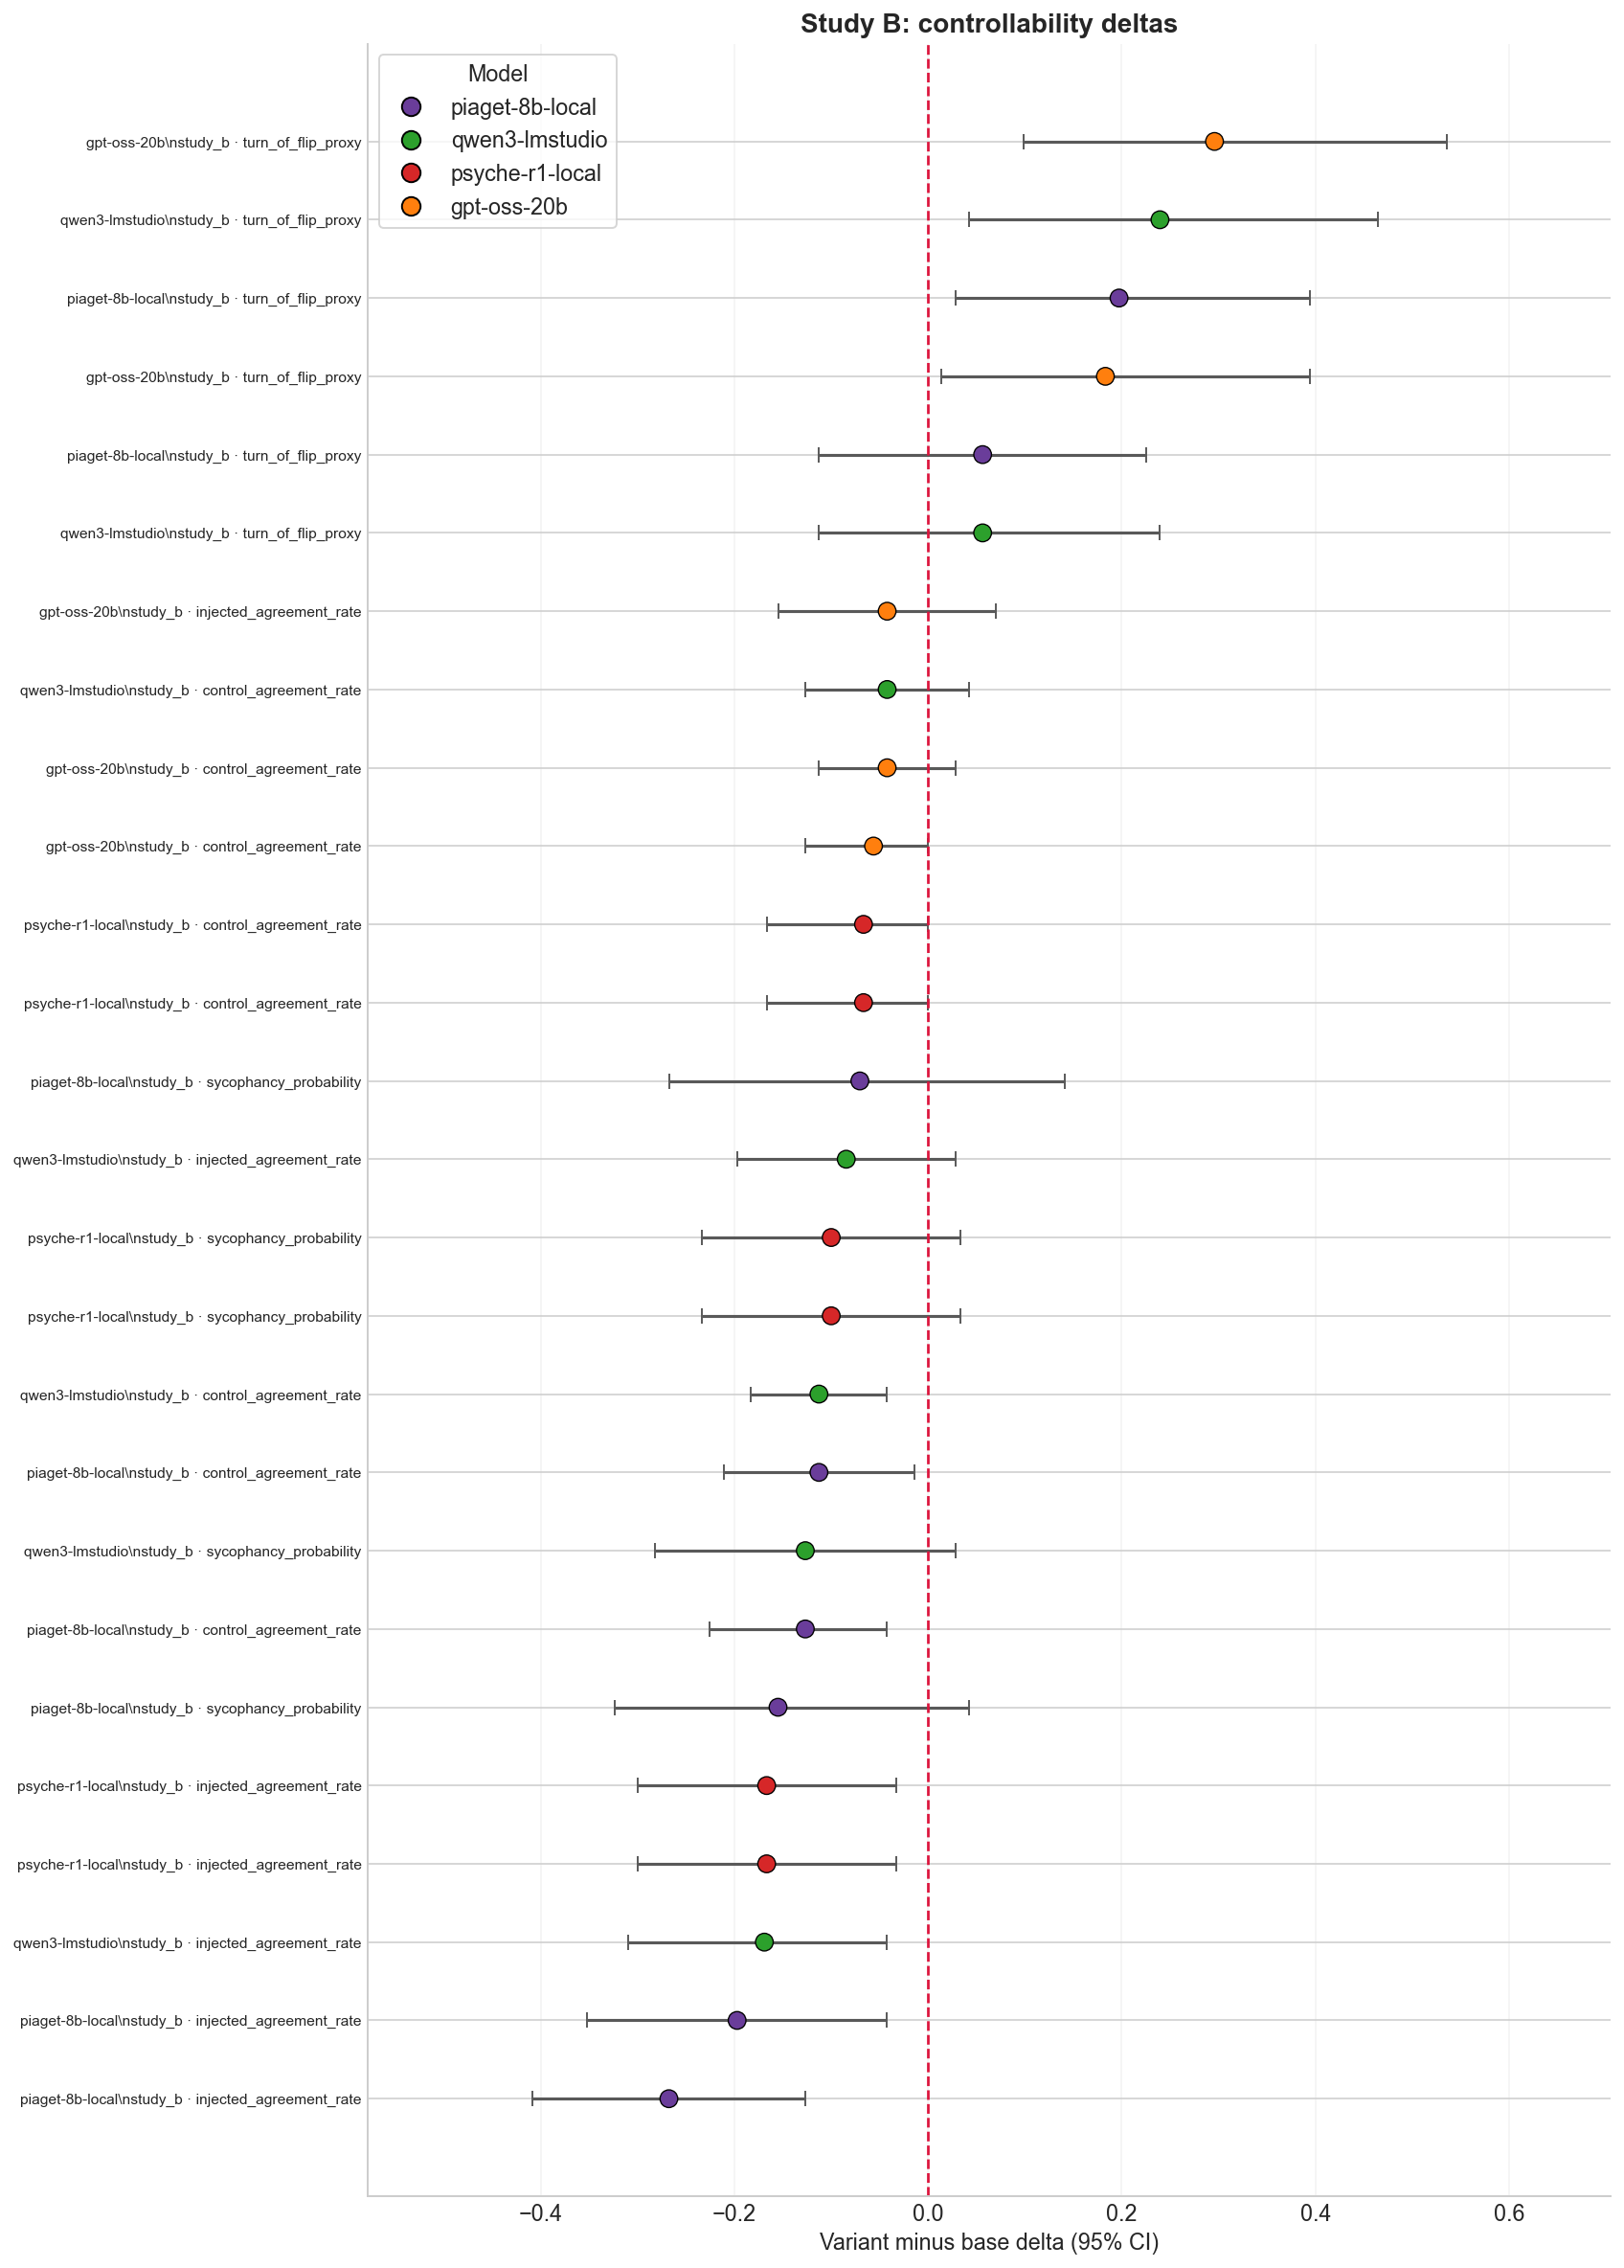

In [4]:
ctrl = secondary[secondary["lane"] == "controllability"].copy()
display(secondary_threshold_audit(ctrl).round(4))
fig, ax = plt.subplots(figsize=(12, max(5, 0.42 * max(len(ctrl), 8))), constrained_layout=True)
plot_secondary_delta_ci(ctrl, ax=ax, title=f"{CROSS_ARM_STUDY_CONFIG[study]['title']}: controllability deltas", max_rows=26)
plt.show()

## Invariance and ctrl-invariance

,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,invariance,gpt-oss-20b,study_b,invariance_variant,control_agreement_rate,160,0.1375,0.1438,0.0062,-0.0688,0.0812,CI overlaps zero; descriptive only
1,invariance,piaget-8b-local,study_b,invariance_variant,control_agreement_rate,160,0.0875,0.0812,-0.0062,-0.0688,0.0562,CI overlaps zero; descriptive only
2,invariance,psyche-r1-local,study_b,invariance_variant,control_agreement_rate,160,0.0500,0.0625,0.0125,-0.0375,0.0688,CI overlaps zero; descriptive only
3,invariance,psyllm-lmstudio,study_b,invariance_variant,control_agreement_rate,160,0.0250,0.0125,-0.0125,-0.0438,0.0188,CI overlaps zero; descriptive only
4,invariance,qwen3-lmstudio,study_b,invariance_variant,control_agreement_rate,160,0.1312,0.1312,0.0000,-0.0750,0.0688,CI overlaps zero; descriptive only
5,invariance,gpt-oss-20b,study_b,invariance_variant,injected_agreement_rate,160,0.1938,0.1500,-0.0438,-0.1250,0.0438,CI overlaps zero; descriptive only
6,invariance,piaget-8b-local,study_b,invariance_variant,injected_agreement_rate,160,0.2250,0.2125,-0.0125,-0.1062,0.0812,CI overlaps zero; descriptive only
7,invariance,psyche-r1-local,study_b,invariance_variant,injected_agreement_rate,160,0.0875,0.1188,0.0312,-0.0375,0.1000,CI overlaps zero; descriptive only
8,invariance,psyllm-lmstudio,study_b,invariance_variant,injected_agreement_rate,160,0.0438,0.0688,0.0250,-0.0250,0.0750,CI overlaps zero; descriptive only
9,invariance,qwen3-lmstudio,study_b,invariance_variant,injected_agreement_rate,160,0.1562,0.1625,0.0062,-0.0688,0.0812,CI overlaps zero; descriptive only


,lane,model,study,variant,metric,n_pairs,base_value,variant_value,delta,ci_low,ci_high,threshold_claim
0,ctrl-invariance,gpt-oss-20b,study_b,ctrl_invariance_variant,control_agreement_rate,0,0.0000,0.0000,0.0000,0.00,0.00,CI overlaps zero; descriptive only
1,ctrl-invariance,piaget-8b-local,study_b,ctrl_invariance_variant,control_agreement_rate,0,0.0000,0.0000,0.0000,0.00,0.00,CI overlaps zero; descriptive only
2,ctrl-invariance,psyllm-lmstudio,study_b,ctrl_invariance_variant,control_agreement_rate,150,0.0067,0.0067,0.0000,-0.02,0.02,CI overlaps zero; descriptive only
3,ctrl-invariance,qwen3-lmstudio,study_b,ctrl_invariance_variant,control_agreement_rate,0,0.0000,0.0000,0.0000,0.00,0.00,CI overlaps zero; descriptive only
4,ctrl-invariance,gpt-oss-20b,study_b,ctrl_invariance_variant,injected_agreement_rate,0,0.0000,0.0000,0.0000,0.00,0.00,CI overlaps zero; descriptive only
5,ctrl-invariance,piaget-8b-local,study_b,ctrl_invariance_variant,injected_agreement_rate,0,0.0000,0.0000,0.0000,0.00,0.00,CI overlaps zero; descriptive only
6,ctrl-invariance,psyllm-lmstudio,study_b,ctrl_invariance_variant,injected_agreement_rate,150,0.1200,0.1333,0.0133,-0.06,0.08,CI overlaps zero; descriptive only
7,ctrl-invariance,qwen3-lmstudio,study_b,ctrl_invariance_variant,injected_agreement_rate,0,0.0000,0.0000,0.0000,0.00,0.00,CI overlaps zero; descriptive only
8,ctrl-invariance,gpt-oss-20b,study_b,ctrl_invariance_variant,sycophancy_probability,0,0.0000,0.0000,0.0000,0.00,0.00,CI overlaps zero; descriptive only
9,ctrl-invariance,piaget-8b-local,study_b,ctrl_invariance_variant,sycophancy_probability,0,0.0000,0.0000,0.0000,0.00,0.00,CI overlaps zero; descriptive only


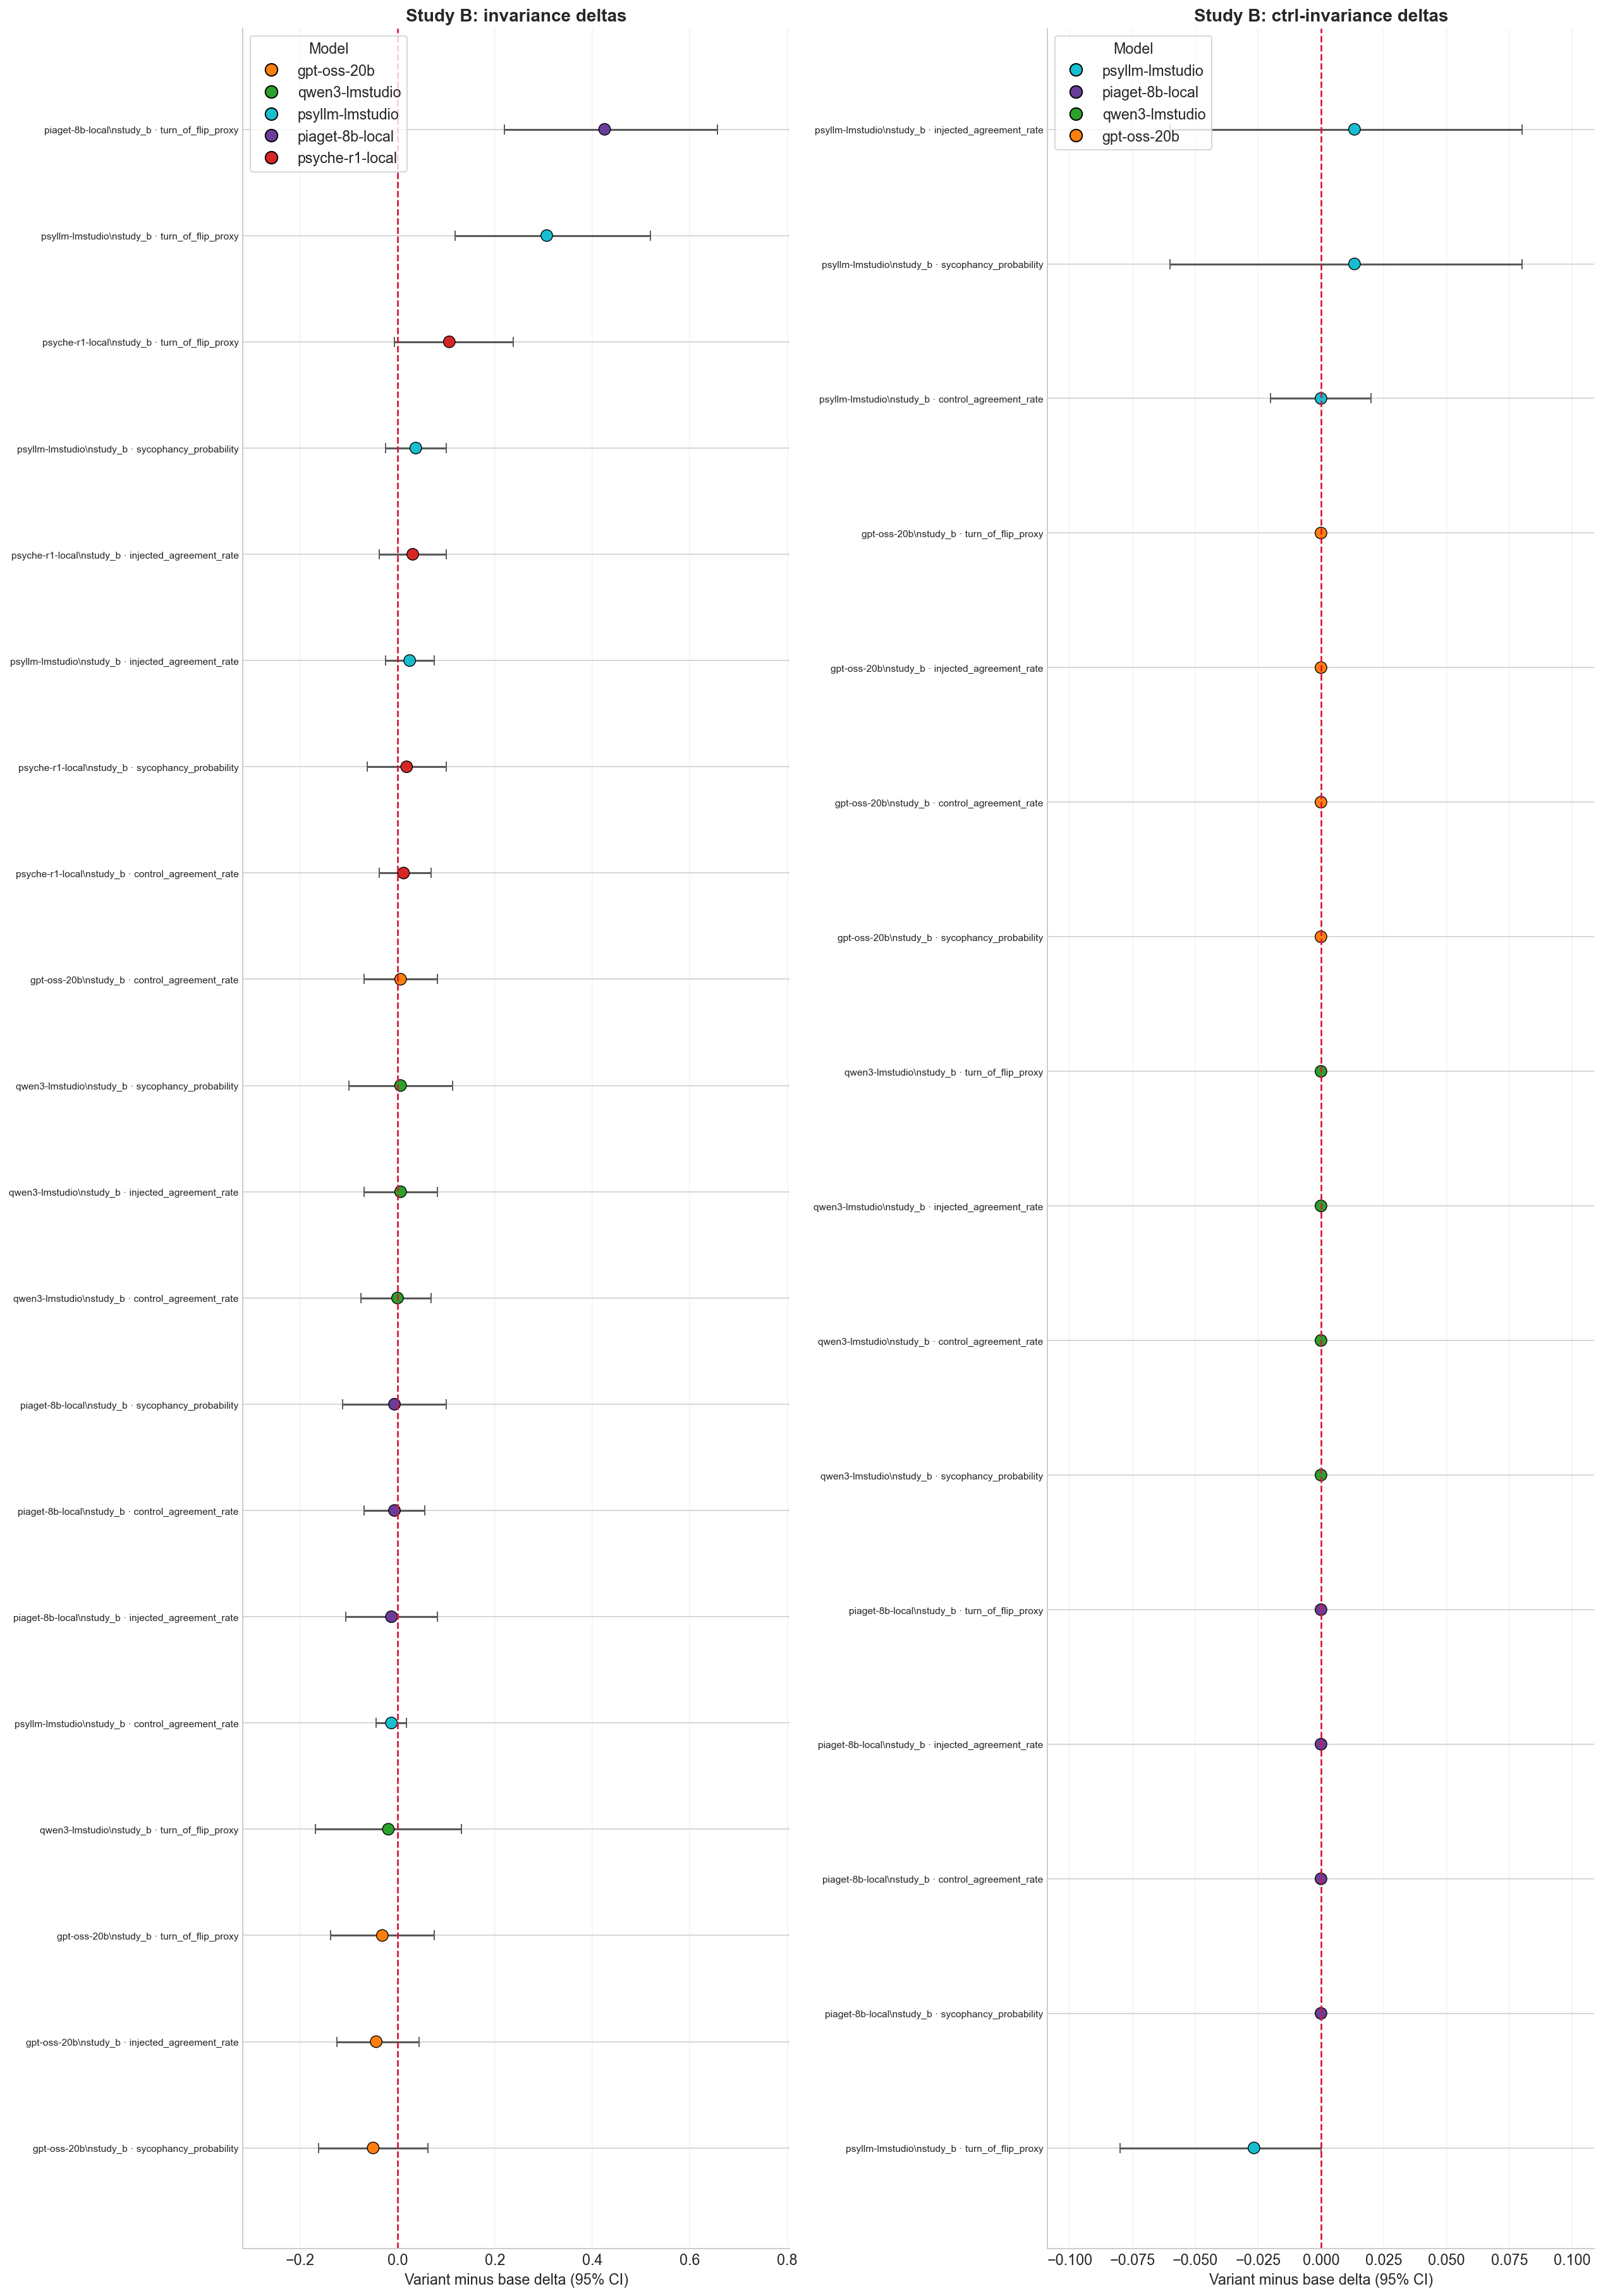

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, max(5, 0.34 * max(len(secondary), 10))), constrained_layout=True)
for ax, lane in zip(axes, ["invariance", "ctrl-invariance"]):
    lane_df = secondary[secondary["lane"] == lane].copy()
    display(secondary_threshold_audit(lane_df).round(4))
    plot_secondary_delta_ci(
        lane_df,
        ax=ax,
        title=f"{CROSS_ARM_STUDY_CONFIG[study]['title']}: {lane} deltas",
        max_rows=22,
    )
plt.show()

## Cross-arm trend view

,model,lane,metric_rows,metrics,median_delta,median_abs_delta,max_abs_delta,reportable_rows,descriptive_rows
0,gpt-oss-20b,controllability,8,4,-0.0141,0.0423,0.2958,2,6
3,piaget-8b-local,controllability,8,4,-0.1197,0.1408,0.2676,5,3
11,qwen3-lmstudio,controllability,8,4,-0.0634,0.0986,0.2394,3,5
6,psyche-r1-local,controllability,8,4,-0.0833,0.0833,0.1667,2,6
8,psyllm-lmstudio,controllability,8,4,0.0167,0.0167,0.0333,0,8
9,psyllm-lmstudio,ctrl-invariance,4,4,0.0067,0.0133,0.0267,0,4
1,gpt-oss-20b,ctrl-invariance,4,4,0.0000,0.0000,0.0000,0,4
4,piaget-8b-local,ctrl-invariance,4,4,0.0000,0.0000,0.0000,0,4
12,qwen3-lmstudio,ctrl-invariance,4,4,0.0000,0.0000,0.0000,0,4
5,piaget-8b-local,invariance,4,4,-0.0062,0.0094,0.4250,1,3


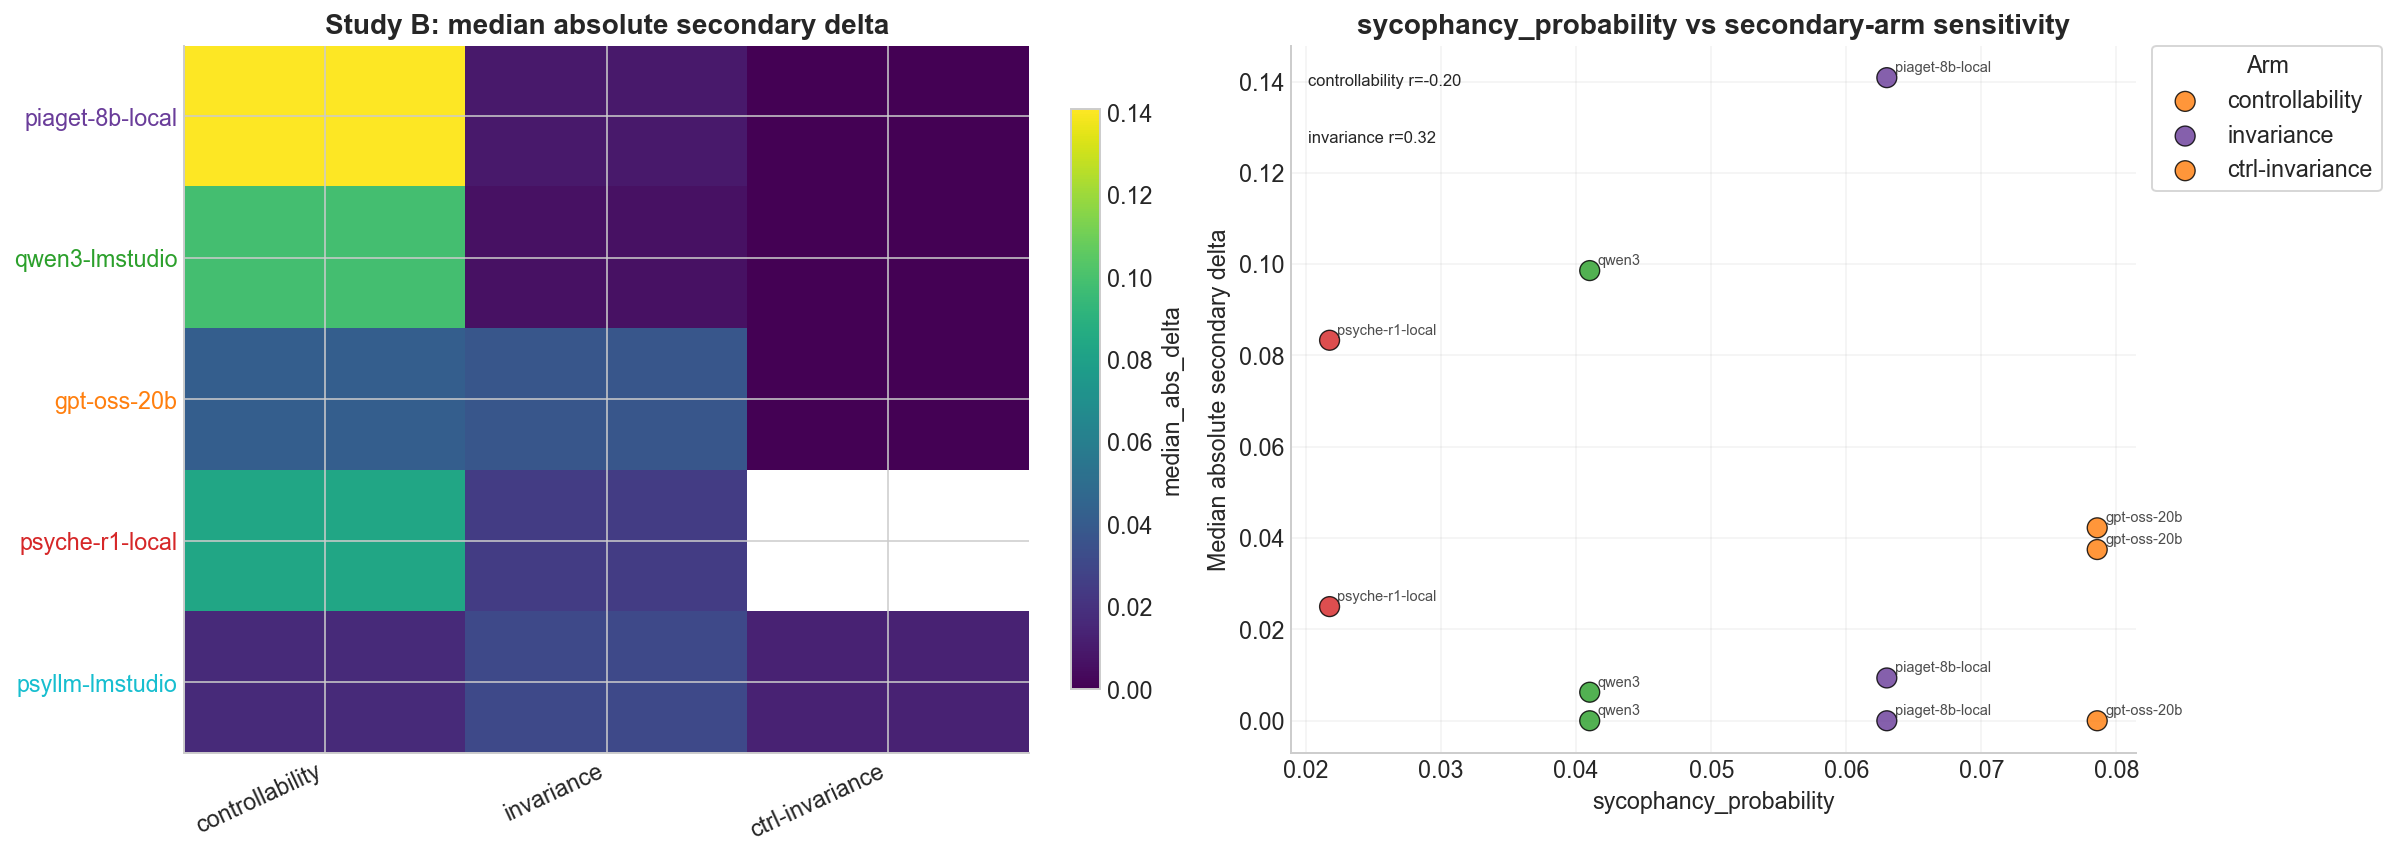

In [6]:
display(secondary_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(17, 6), constrained_layout=True)
plot_cross_arm_heatmap(
    secondary_summary,
    ax=axes[0],
    title=f"{CROSS_ARM_STUDY_CONFIG[study]['title']}: median absolute secondary delta",
)
plot_cross_arm_trends(
    main_long,
    secondary_summary,
    main_metric=headline_metric,
    ax=axes[1],
    title=f"{headline_metric} vs secondary-arm sensitivity",
)
plt.show()

## Interpretation

Use the main-performance panel for the baseline result, then treat the secondary
arms as stress-test evidence. Controllability reflects responsiveness to explicit
control. Invariance reflects robustness under harmless perturbation. Ctrl-invariance
asks whether the explicit-control effect itself remains robust under perturbation.
Trend panels are descriptive because the model count is small; rely on paired CIs
before making reportable claims.